# Neuronové sítě - učení s učitelem - klasifikace

In [26]:
import tensorflow as tf   # nezapomeňte v Anaconda přepnout prostředí na tensorflow!!!
#print(tf.__version__)  # tisk verze tensorflow

import numpy as np
import matplotlib.pyplot as plt   # možná bude potřeba doinstalovat v novém prostředí!!!
import tensorflow_datasets as tfds

## Load dataset
---

seznam datasetů v TensorFlow https://www.tensorflow.org/datasets/catalog/overview#all_datasets


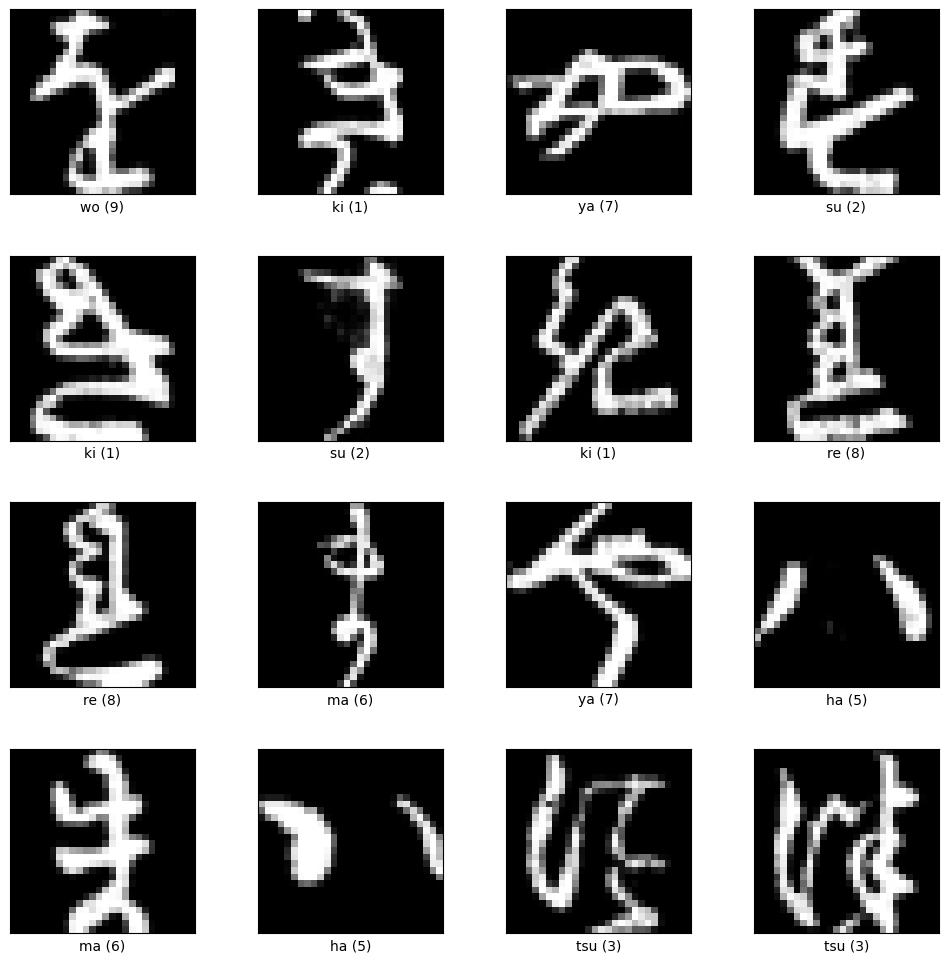

In [28]:
(ds_train, ds_test), ds_info = tfds.load(
    #"mnist",
    "kmnist",
    split=["train", "test"],
    shuffle_files=True,
    as_supervised=True, #(img, label)
    with_info=True    
)

#Shows examples
fig = tfds.show_examples(ds_train, ds_info, rows = 4, cols=4)

#Shows info
#print(ds_info)



In [29]:
def normalize_img(image, label):
    #normalize images
    return tf.cast(image, tf.float32)/255.0, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 64
ds_train = ds_train.map(normalize_img, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(1000)
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(AUTOTUNE)

ds_test = ds_test.map(normalize_img, num_parallel_calls=AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.prefetch(AUTOTUNE)




## Neuronová síť - stavba
---
různé typy vrstev v tf.keras.layers - (https://www.tensorflow.org/api_docs/python/tf/keras/layers)

různé typy aktivačních funkcí - (https://www.tensorflow.org/api_docs/python/tf/keras/activations)

In [30]:
model = tf.keras.Sequential([
    
    #For mnists-px
    tf.keras.Input((28, 28, 1)), 

   
    # first convolution layer
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    
    # second convolution layer
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    
    # fully connected classification
    # single vector
    tf.keras.layers.Flatten(),
    
    # hidden layer and output layer
    tf.keras.layers.Dense(1024, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
   
])

In [31]:
# optimizer - způsob jakým se učíme z chyb na základě dat  
# loss - měření chyby vstup-výstup, snažíme se minimalizovat
# metrics - monitorování, jak nám jde trénování 


model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

## Neuronové síť - učení
---

In [32]:
model.fit(ds_train, epochs=5, verbose=2)


Epoch 1/5
938/938 - 40s - 42ms/step - accuracy: 0.9310 - loss: 0.2282
Epoch 2/5
938/938 - 33s - 35ms/step - accuracy: 0.9817 - loss: 0.0598
Epoch 3/5
938/938 - 32s - 35ms/step - accuracy: 0.9907 - loss: 0.0302
Epoch 4/5
938/938 - 37s - 39ms/step - accuracy: 0.9947 - loss: 0.0161
Epoch 5/5
938/938 - 34s - 36ms/step - accuracy: 0.9953 - loss: 0.0140


## Neuronová síť - evaluace
---

In [33]:
test_loss, test_acc = model.evaluate(ds_test)


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9573 - loss: 0.2186


## Neuronová síť - predikce
---

In [196]:
pr_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()]) # přidání softmax vrstvy

In [197]:
predictions = pr_model.predict(ds_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [198]:
#transforms ds_test to usable list of BATCHES
test_data = [(example.numpy(), label.numpy()) for example, label in ds_test]
#print((test_data[0][0][100]))

In [199]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# shows sample s and its class c
def show_sample(s, c):

    plt.figure()
    plt.imshow(s, cmap=plt.cm.binary)
    plt.colorbar()
    plt.grid(False)
    plt.title(c)
    plt.show()
    
#show_sample(test_data[0][0][100], test_data[0][1][100])    


# zobrazí predikci vzorku číslo i
def sample_predict(i, test_image, test_label, predictions, class_names):
    s = test_image[i]
    c = class_names[test_label[i]]
    show_sample(s, c)
    
    print("Probabilities")
    print("------------")
    for j in range(len(class_names)):
        print(class_names[j], ":", np.round(predictions[i, j], 2))
    
    ind = np.argmax(predictions[i])
    
    print("------------")
    print("true class:", c, ", predicted class:", class_names[ind])

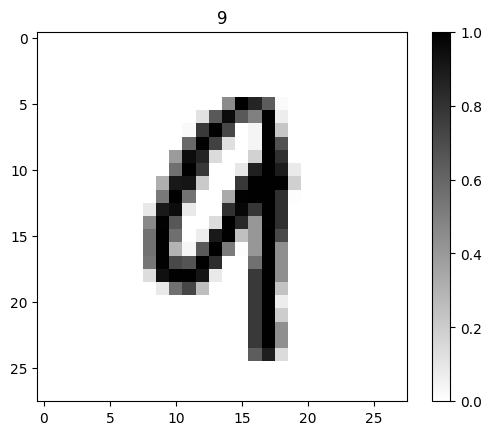

Probabilities
------------
0 : 0.0
1 : 0.0
2 : 0.0
3 : 0.0
4 : 0.01
5 : 0.0
6 : 0.0
7 : 0.0
8 : 0.0
9 : 0.99
------------
true class: 9 , predicted class: 9


In [201]:
sample_predict(42, test_data[0][0], test_data[0][1],
               predictions, class_names)

## Otázky
---

- Kolik položek jednoho typu bylo klasifikováno správně? 